# Logistics Data Analytics Project
## EDA & Database Loading

**Objective:** Load the logistics dataset into SQLite, verify storage, and perform exploratory data analysis.

## STEP 1: Load Dataset into Database

### 1.1 Import Libraries

In [16]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print("Libraries imported successfully")

Libraries imported successfully


### 1.2 Read CSV Dataset

In [17]:
# df = pd.read_csv('../data/logistics_heavy.csv', low_memory=False)

chunks = pd.read_csv('../data/logistics_heavy.csv', chunksize=50000)
df = pd.concat(chunks)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nData types:")
print(df.dtypes)

Dataset shape: (400000, 20)

First 5 rows:


,shipment_id,order_id,customer_name,origin_city,destination_city,origin_country,destination_country,ship_date,delivery_date,weight_kg,volume_m3,shipping_mode,status,base_cost_usd,surcharge_usd,total_cost_usd,currency,payment_terms,created_at,last_update
0,SHP-288390,53737,nguyen kim,Phnom Penh,Saigon,TH,Cambodia,"Oct 15, 2021","Jan 14, 2021",301.9,2.497,rail,LOST,1259.14,726.46,2305.8,THB,PrePaid,2023-02-21T13:50:23Z,2023-07-06T05:55:19Z
1,74871,382273,Vann Lee,Bangkok,Phnom Penh,Cambodia,VN,05/14/2022,08/08/2021,269.53,1.862,TRK,DELIVERED,"99,0",free,NaN,NaN,cod,2023-10-11 00:25:04,2023-10-02T09:42:53Z
2,918399,ORD-399488,Dara Smith,Bangkok,Phnompenh,NaN,Vietnam,04/03/2021,2020-11-18,488.99,2.648,trk,DELIVERED,849.16,1080.9,error,usd,cod,29/10/2023 20:10,2023-05-07 08:10:51
3,SHP-070675,ORD-37150,Nguyen Lee,HCMC,HCMC,Thailand,VN,"Aug 10, 2024","Sep 05, 2020",54.72,3.523,Air Freight,INTRANSIT,155.39,1712.65,1868.04,NaN,prepaid,2023-04-20 14:36:05,2023-05-02 06:03:18
4,823268,ORD-382996,Nguyen Garcia,Phnom Penh,Phnom Penh,VNM,NaN,2025-09-11,NaN,201.95,1.766,air,LOST,636.16,1341.1,1977.2599999999998,KHR,credit 30d,2023-02-07 00:20:20,2023-10-16 03:38:24



Data types:
shipment_id                str
order_id                   str
customer_name              str
origin_city                str
destination_city           str
origin_country             str
destination_country        str
ship_date                  str
delivery_date              str
weight_kg                  str
volume_m3              float64
shipping_mode              str
status                     str
base_cost_usd              str
surcharge_usd              str
total_cost_usd             str
currency                   str
payment_terms              str
created_at                 str
last_update                str
dtype: object


### 1.3 Connect to SQLite Database

In [18]:
DB_PATH = '../database/data.sqlite'
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)
conn = sqlite3.connect(DB_PATH)
print(f"Connected to SQLite database: {DB_PATH}")

Connected to SQLite database: ../database/data.sqlite


### 1.4 Create Table and Load Data

In [19]:
df.to_sql('shipments', conn, if_exists='replace', index=False)
print("Data loaded into 'shipments' table successfully")

Data loaded into 'shipments' table successfully


### 1.5 Verify Database Storage

In [20]:
query_count = "SELECT COUNT(*) AS total_rows FROM shipments"
result = pd.read_sql_query(query_count, conn)
print(f"Total rows in shipments table: {result['total_rows'].iloc[0]:,}")

Total rows in shipments table: 400,000


In [21]:
query_first10 = "SELECT * FROM shipments LIMIT 10"
first10 = pd.read_sql_query(query_first10, conn)
print("First 10 rows from database:")
display(first10)

First 10 rows from database:


,shipment_id,order_id,customer_name,origin_city,destination_city,origin_country,destination_country,ship_date,delivery_date,weight_kg,volume_m3,shipping_mode,status,base_cost_usd,surcharge_usd,total_cost_usd,currency,payment_terms,created_at,last_update
0,SHP-288390,53737,nguyen kim,Phnom Penh,Saigon,TH,Cambodia,"Oct 15, 2021","Jan 14, 2021",301.9,2.497,rail,LOST,1259.14,726.46,2305.8,THB,PrePaid,2023-02-21T13:50:23Z,2023-07-06T05:55:19Z
1,74871,382273,Vann Lee,Bangkok,Phnom Penh,Cambodia,VN,05/14/2022,08/08/2021,269.53,1.862,TRK,DELIVERED,"99,0",free,NaN,NaN,cod,2023-10-11 00:25:04,2023-10-02T09:42:53Z
2,918399,ORD-399488,Dara Smith,Bangkok,Phnompenh,NaN,Vietnam,04/03/2021,2020-11-18,488.99,2.648,trk,DELIVERED,849.16,1080.9,error,usd,cod,29/10/2023 20:10,2023-05-07 08:10:51
3,SHP-070675,ORD-37150,Nguyen Lee,HCMC,HCMC,Thailand,VN,"Aug 10, 2024","Sep 05, 2020",54.72,3.523,Air Freight,INTRANSIT,155.39,1712.65,1868.04,NaN,prepaid,2023-04-20 14:36:05,2023-05-02 06:03:18
4,823268,ORD-382996,Nguyen Garcia,Phnom Penh,Phnom Penh,VNM,NaN,2025-09-11,NaN,201.95,1.766,air,LOST,636.16,1341.1,1977.2599999999998,KHR,credit 30d,2023-02-07 00:20:20,2023-10-16 03:38:24
5,72133,82705,Maria Smith,Phnom Penh,BKK,KH,KHM,14/03/21,"Dec 17, 2022",25.49,1.766,NaN,DELIVERED,1483.76,858.24,3239.24,KHR,PrePaid,2023-10-10 05:23:30,2023-06-07 13:16:35
6,SHP-818012,ORD-325406,Dara Lee,Phnom Penh,Ho Chi Minh,VN,Thailand,"Mar 18, 2021",02/28/2025,NaN,3.579,truck,Delivered,1284.76,1962.39,3247.15,USD,credit 30d,2023-05-16 01:23:34,2023-06-26 11:25:14
7,267096,NaN,John Kim,Bangkok,PP,Vietnam,KH,05/15/2023,"Feb 24, 2022",374.09,2.767,TRK,delivered,1572.59,647.89,2220.48,NaN,PrePaid,2023-12-04T03:05:14Z,2023-11-21T22:32:47Z
8,845743,128369,maria smith,Bangkok,Saigon,Thailand,Cambodia,"Mar 12, 2021",2022-10-17,333.82,1.531,trk,RETURNED,894.6,1723.68,2618.28,usd,PrePaid,2023-11-17T08:42:38Z,01/01/2024 10:24
9,SHP-242496,112173,Chan Tran,Saigon,Phnom Penh,VN,Vietnam,"May 16, 2024",22/06/25,194.49,2.543,Air Freight,DELIVERED,1814.32,1327.68,3142.0,VND,credit 30d,2023-07-14 10:07:51,2023-04-19T16:33:18Z


In [22]:
query_last10 = "SELECT * FROM shipments ORDER BY rowid DESC LIMIT 10"
last10 = pd.read_sql_query(query_last10, conn)
print("Last 10 rows from database:")
display(last10)

Last 10 rows from database:


,shipment_id,order_id,customer_name,origin_city,destination_city,origin_country,destination_country,ship_date,delivery_date,weight_kg,volume_m3,shipping_mode,status,base_cost_usd,surcharge_usd,total_cost_usd,currency,payment_terms,created_at,last_update
0,SHP-851018,ORD-178157,Srey Kim,HCMC,Phnompenh,KHM,Thailand,2025-07-01,22/09/23,unknown,1.298,truck,returned,$641.22,495.62,error,USD,cod,2023-03-21 06:16:45,30/01/2023 17:11
1,817262,279941,DARA SMITH,HCMC,NaN,Cambodia,NaN,2021-07-02,"Sep 09, 2020",NaN,3.111,Sea,delivered,1368.18,1090.14,2458.32,KHR,credit 30d,2023-01-04T13:52:46Z,22/04/2023 21:47
2,188454,ORD-230997,Chan Garcia,Ho Chi Minh,PP,NaN,VN,2022-09-08,07/06/2021,410.06,3.023,AIR,delivered,"1042,06",1101.31,error,THB,COD,2023-07-10 16:32:40,2023-05-05T03:47:34Z
3,748724,ORD-1728,Vann Smith,HCMC,Ho Chi Minh,Vietnam,VNM,2020-05-25,2021-10-25,414.56,3.103,Sea,returned,232.35,835.87,1068.22,KHR,cod,2023-02-13 08:04:32,2023-09-23T17:58:12Z
4,SHP-505012,ORD-494350,NGUYEN KIM,Phnompenh,Saigon,NaN,KHM,"May 16, 2022",2021-02-27,331.54,0.640,trk,INTRANSIT,1400.67,1588.6,1503.31,NaN,PrePaid,2023-03-23T08:49:01Z,2023-04-03T02:32:51Z
5,SHP-195258,ORD-450778,Maria Nguyen,PP,Bangkok,TH,VNM,2025-12-20,"Apr 23, 2024",192.31,NaN,air,RETURNED,367.3,867.46,error,THB,collect,2023-12-22T13:31:54Z,2023-05-29T15:16:02Z
6,821783,168340,John Lee,Phnom Penh,Saigon,Thailand,NaN,2024-06-04,"Oct 20, 2024",275.59,1.781,trk,??,1459.42,624.74,1394.26,USD,credit 30d,30/03/2023 20:22,2023-06-09T06:59:31Z
7,254020,ORD-36519,NaN,BKK,PP,KH,VNM,2020-07-02,NaN,442.04,4.130,air,lost,801.25,673.4,1474.65,usd,credit 30d,2023-11-26 23:26:32,04/08/2023 11:20
8,898483,ORD-114437,Chan Smith,BKK,PP,VNM,KHM,07/22/2025,NaN,408.14,NaN,sea,RETURNED,267.8,18.27,286.07,NaN,NaN,16/11/2023 00:19,17/01/2023 18:53
9,767730,ORD-247066,Vann Lee,Phnompenh,Phnompenh,KHM,NaN,2023-09-19,"Feb 08, 2023",412.07,1.493,Air Freight,RETURNED,577.53,164.34,741.87,THB,NaN,24/01/2023 12:02,2023-12-31T03:19:42Z


In [23]:
query_100 = "SELECT * FROM shipments LIMIT 100"
sample100 = pd.read_sql_query(query_100, conn)
print(f"Sample of 100 rows from database (shape: {sample100.shape}):")
display(sample100)

Sample of 100 rows from database (shape: (100, 20)):


,shipment_id,order_id,customer_name,origin_city,destination_city,origin_country,destination_country,ship_date,delivery_date,weight_kg,volume_m3,shipping_mode,status,base_cost_usd,surcharge_usd,total_cost_usd,currency,payment_terms,created_at,last_update
0,SHP-288390,53737,nguyen kim,Phnom Penh,Saigon,TH,Cambodia,"Oct 15, 2021","Jan 14, 2021",301.9,2.497,rail,LOST,1259.14,726.46,2305.8,THB,PrePaid,2023-02-21T13:50:23Z,2023-07-06T05:55:19Z
1,74871,382273,Vann Lee,Bangkok,Phnom Penh,Cambodia,VN,05/14/2022,08/08/2021,269.53,1.862,TRK,DELIVERED,"99,0",free,NaN,NaN,cod,2023-10-11 00:25:04,2023-10-02T09:42:53Z
2,918399,ORD-399488,Dara Smith,Bangkok,Phnompenh,NaN,Vietnam,04/03/2021,2020-11-18,488.99,2.648,trk,DELIVERED,849.16,1080.9,error,usd,cod,29/10/2023 20:10,2023-05-07 08:10:51
3,SHP-070675,ORD-37150,Nguyen Lee,HCMC,HCMC,Thailand,VN,"Aug 10, 2024","Sep 05, 2020",54.72,3.523,Air Freight,INTRANSIT,155.39,1712.65,1868.04,NaN,prepaid,2023-04-20 14:36:05,2023-05-02 06:03:18
4,823268,ORD-382996,Nguyen Garcia,Phnom Penh,Phnom Penh,VNM,NaN,2025-09-11,NaN,201.95,1.766,air,LOST,636.16,1341.1,1977.2599999999998,KHR,credit 30d,2023-02-07 00:20:20,2023-10-16 03:38:24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,865340,28870,srey kim,Ho Chi Minh,Phnom Penh,KHM,TH,"Dec 27, 2021",NaN,161.48,1.192,TRK,Delivered,1390.77,1056.47,2447.24,NaN,cod,2023-11-19 19:15:30,2023-12-19T22:01:09Z
96,653519,294983,Maria Smith,Bangkok,NaN,Cambodia,KH,"Apr 29, 2022",16/02/20,34.01,1.498,air,lost,1233.91,$355.38,NaN,USD,COD,2023-08-24T19:33:01Z,2023-07-31T02:02:22Z
97,SHP-605446,ORD-465584,Srey Kim,Phnompenh,Saigon,KH,TH,2023-07-12,24/05/23,NaN,2.915,AIR,delivered,312.39,969.53,658.04,NaN,collect,2023-09-25 04:13:02,2023-01-19 16:43:30
98,349480,272933,Lina Kim,Bangkok,Ho Chi Minh,KH,KHM,2020-03-03,06/03/23,446.13,NaN,air,delivered,"855,8",1194.26,error,THB,PrePaid,2023-12-10 19:25:24,27/08/2023 20:40


✅ **Database Verification Complete**

The CSV dataset has been successfully loaded into SQLite. The `shipments` table contains all 400,000 rows. We have verified this by:
- Counting total rows (COUNT query)
- Displaying first 10 rows
- Displaying last 10 rows
- Displaying a 100-row sample

---
## STEP 2: Exploratory Data Analysis

### 2.1 Dataset Overview

In [24]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumns:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing cells: {df.isnull().sum().sum()}")

DATASET OVERVIEW
Shape: (400000, 20)

Columns:
  shipment_id: str
  order_id: str
  customer_name: str
  origin_city: str
  destination_city: str
  origin_country: str
  destination_country: str
  ship_date: str
  delivery_date: str
  weight_kg: str
  volume_m3: float64
  shipping_mode: str
  status: str
  base_cost_usd: str
  surcharge_usd: str
  total_cost_usd: str
  currency: str
  payment_terms: str
  created_at: str
  last_update: str

Memory usage: 401.85 MB
Duplicate rows: 0
Missing cells: 659033


### 2.2 Missing Value Analysis

In [25]:
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing': df.isnull().sum().values,
    'Percent': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing = missing[missing['Missing'] > 0].sort_values('Percent', ascending=False)
print("Missing Value Report:")
display(missing)

Missing Value Report:


,Column,Missing,Percent
17,payment_terms,84698,21.17
16,currency,82687,20.67
15,total_cost_usd,71431,17.86
6,destination_country,62198,15.55
5,origin_country,62170,15.54
1,order_id,60039,15.01
8,delivery_date,40384,10.10
0,shipment_id,39998,10.00
10,volume_m3,39936,9.98
2,customer_name,27819,6.95


**Key Observations:**
- payment_terms (21.17%) and currency (20.67%) have the highest missing rates
- total_cost_usd (17.86%) missing is significant since it's our target variable
- destination/origin country columns both missing ~15.5% — likely systemic collection gaps
- All columns have some missing data, suggesting inconsistent data entry

### 2.3 Duplicate Analysis

In [26]:
dups = df.duplicated().sum()
print(f"Exact duplicate rows: {dups} ({dups / len(df) * 100:.2f}%)")
if dups > 0:
    print(f"\nSample duplicates:")
    display(df[df.duplicated(keep=False)].head(10))

Exact duplicate rows: 0 (0.00%)


### 2.4 Numerical Summary Statistics

In [27]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns: {num_cols}")
if num_cols:
    display(df[num_cols].describe())

Numerical columns: ['volume_m3']


,volume_m3
count,360064.000000
mean,2.016783
std,0.964707
min,0.000000
25%,1.326000
50%,2.000000
75%,2.674000
max,6.562000


### 2.5 Categorical Analysis

In [28]:
cat_cols = df.select_dtypes(include=['object','str','string']).columns.tolist()
for col in cat_cols[:6]:
    n_unique = df[col].nunique()
    print(f"\n{'='*50}")
    print(f"{col} ({n_unique} unique values)")
    print('='*50)
    print(df[col].value_counts().head(10).to_string())


shipment_id (325170 unique values)
shipment_id
931424    5
534058    5
646438    5
562445    5
368763    5
897175    5
16952     4
996392    4
216235    4
972117    4

order_id (286193 unique values)
order_id
ORD-224932    6
ORD-264632    6
ORD-410729    6
ORD-487362    5
ORD-475815    5
ORD-488581    5
ORD-288629    5
ORD-215570    5
ORD-94652     5
ORD-241114    5

customer_name (324 unique values)
customer_name
Sok Lee          5195
Srey Nguyen      5125
Maria Garcia     5111
Dara Tran        5107
Vann Tran        5099
Dara Garcia      5096
Chan Garcia      5095
Dara Lee         5092
Maria Smith      5089
Nguyen Garcia    5084

origin_city (8 unique values)
origin_city
BKK            48750
Phnompenh      48660
Saigon         48581
HCMC           48543
Phnom Penh     48507
Bangkok        48474
PP             48421
Ho Chi Minh    48208

destination_city (8 unique values)
destination_city
PP             48647
Phnom Penh     48628
Bangkok        48556
Saigon         48523
Phnompenh    

**Categorical Insights:**
- shipping_mode has 9 variants (air, trk, sea, rail, and mixed case) — needs standardization
- status has 10 variants with case inconsistencies (e.g., 'Delivered', 'DELIVERED', 'delivered')
- origin/destination have duplicate city names (e.g., 'BKK' vs 'Bangkok', 'PP' vs 'Phnom Penh')
- currency has both uppercase and lowercase ('USD' vs 'usd')

### 2.6 Correlation Analysis

In [29]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
    plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../preprocessing/correlation_heatmap.png', dpi=150)
    plt.show()
else:
    print("Insufficient numerical columns for correlation analysis.")
    print("Most numeric data is stored as strings and will be converted during cleaning.")

Insufficient numerical columns for correlation analysis.
Most numeric data is stored as strings and will be converted during cleaning.


### 2.7 Distribution Plots

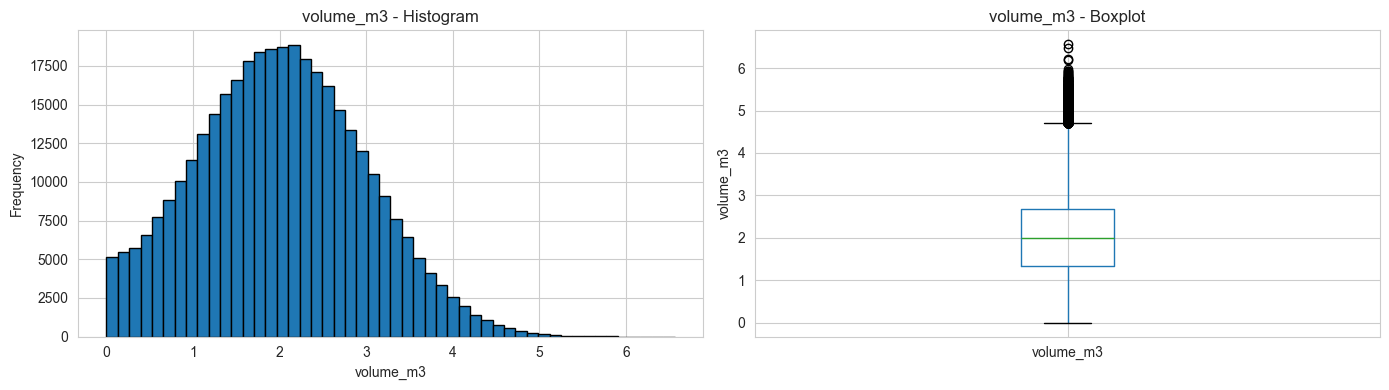

In [30]:
if num_cols:
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        df[col].hist(bins=50, ax=axes[0], edgecolor='black')
        axes[0].set_title(f'{col} - Histogram')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')
        df.boxplot(column=col, ax=axes[1])
        axes[1].set_title(f'{col} - Boxplot')
        axes[1].set_ylabel(col)
        plt.tight_layout()
        plt.savefig(f'../preprocessing/{col}_distribution.png', dpi=100)
        plt.show()
else:
    print("No numerical columns available for distribution plots yet.")